# Phase 2 — Multi-model Experiment: Breaking the Codec Shortcut

**Date:** 2026-05-05 (Tue)
**Project:** DL-2 Deepfake Audio Detection
**Author:** Anthony

## The Phase 1 problem we're attacking

Phase 1 ended with LogReg + RandomForest at **0.00% EER** on `garystafford/deepfake-audio-detection`. XGBoost feature-importance traced 66.4% of the model's signal to ONE feature — `spec_contrast6_mean`, the mean of the highest-frequency spectral-contrast band. The whole spectral-contrast family did 87% of the work; prosody (jitter / shimmer / F0) — the forensic signal the literature recommends — contributed 0%.

That's a textbook codec / sample-rate / source leak. The model isn't learning vocoder behavior; it's learning that fakes were sampled / encoded differently. Müller et al. 2022 showed lab-trained detectors at <1% EER routinely collapse to >30% EER on real-world recordings.

## Phase 2 questions

1. **Ablation** — if we drop the leaky family, does ANY real signal remain? (2.1, 2.2)
2. **Deep learning** — does an end-to-end mel-CNN find different signal than the handcrafted pipeline? (2.3)
3. **SSL features** — does a frozen Wav2Vec2 (the SOTA front-end on 11/13 datasets per the 2026 LoRA-MoE paper) beat handcrafted features here? (2.4)
4. **Generalization** — does any of this transfer to a SECOND dataset (`Hemg/Deepfake-Audio-Dataset`)? (2.5) — this is the headline.

## Research grounding (read before experimenting)

- **Müller et al. 2022 (arXiv:2203.16263)** — "Does Audio Deepfake Detection Generalize?" Lab-trained detectors collapse on real-world data. This is the test we're applying in 2.5.
- **Tak et al. 2022 (Wav2Vec2 + AASIST, arXiv:2202.12233)** — Wav2Vec2 front-end, 0.82% EER on ASVspoof 2021 LA. Motivates using frozen Wav2Vec2 features in 2.4.
- **Mixture of LoRA Experts in Generalizable Audio Deepfake Detection (arXiv:2509.13878, 2026)** — "Wav2Vec2 achieves the lowest macro-average EER on 11 of 13 evaluation datasets." Confirms Wav2Vec2 as the right SSL front-end to compare against.
- **Frank & Schönherr 2021 (WaveFake, arXiv:2111.02813)** — handcrafted classifiers should land in 6-12% EER on properly hard data. Anything <1% EER is the canary for shortcut learning.

**Primary metric:** Equal Error Rate (EER %), lower = better. Secondary: AUROC, F1@EER threshold.


In [1]:
import json, time, warnings, os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
np.random.seed(42)

REPO = Path('..').resolve()
sys.path.insert(0, str(REPO / 'src'))
from eer import compute_eer, metrics_at_threshold  # noqa

print('REPO :', REPO)
print('numpy:', np.__version__, '| pandas:', pd.__version__)


REPO : /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Deepfake-Audio-Detection
numpy: 2.4.4 | pandas: 3.0.2


## Load Phase 1 cached features

Phase 1 saved the 303-dim handcrafted feature vector for all 1,866 garystafford clips
to `results/phase1_X.npy` and `results/phase1_y.npy`. We use the SAME train/val/test
split (seed=42, stratified, 60/20/20) so Phase 2 numbers are directly comparable to
Phase 1's leaderboard.


In [2]:
X_full = np.load(REPO / 'results/phase1_X.npy')
y_full = np.load(REPO / 'results/phase1_y.npy')
feat_names = json.loads((REPO / 'results/phase1_feature_names.json').read_text())

# Reproduce Phase 1's split: 60/20/20 stratified, seed=42
X_train_full, X_temp, y_train, y_temp = train_test_split(
    X_full, y_full, test_size=0.4, stratify=y_full, random_state=42
)
X_val_full, X_test_full, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f'Total      : {X_full.shape[0]} ({np.bincount(y_full).tolist()})')
print(f'Train      : {X_train_full.shape[0]} | Val: {X_val_full.shape[0]} | Test: {X_test_full.shape[0]}')
print(f'Feature dim: {X_train_full.shape[1]}')

# Family masks for ablation
def mask(prefixes):
    return np.array([any(n.startswith(p) for p in prefixes) for n in feat_names], dtype=bool)

m_mfcc       = mask(['mfcc_'])                                        # 240
m_spec       = mask(['spec_centroid', 'spec_bandwidth', 'spec_rolloff',
                     'spec_flatness', 'spec_zcr', 'spec_rms'])         # 24
m_contrast   = mask(['spec_contrast'])                                 # 28
m_prosody    = mask(['f0_', 'jitter_', 'shimmer_', 'voicing_', 'voiced_'])  # 11

print('Family sizes:')
print(f'  mfcc        : {m_mfcc.sum()}')
print(f'  spec        : {m_spec.sum()}')
print(f'  spec_contrast: {m_contrast.sum()}')
print(f'  prosody     : {m_prosody.sum()}')
print(f'  total covered: {(m_mfcc | m_spec | m_contrast | m_prosody).sum()} / {len(feat_names)}')


Total      : 1866 ([933, 933])
Train      : 1119 | Val: 373 | Test: 374
Feature dim: 303
Family sizes:
  mfcc        : 240
  spec        : 24
  spec_contrast: 28
  prosody     : 11
  total covered: 303 / 303


## Helper: train + eval one model on a feature subset

Returns a dict with EER %, AUROC, F1, precision, recall at the EER threshold,
plus train time. Pipeline = StandardScaler → classifier. Fit on train, threshold
chosen on val (EER on val), evaluated on held-out test.


In [3]:
from sklearn.metrics import roc_auc_score

def evaluate_classifier(clf, X_train, X_val, X_test, y_train, y_val, y_test, name='clf'):
    """Fit on train, pick EER threshold on val, report on test."""
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_s = time.time() - t0

    proba_val  = pipe.predict_proba(X_val)[:, 1]
    proba_test = pipe.predict_proba(X_test)[:, 1]

    eer_val,  thr = compute_eer(y_val,  proba_val)
    eer_test, _   = compute_eer(y_test, proba_test)
    m = metrics_at_threshold(y_test, proba_test, thr)
    auroc_test = roc_auc_score(y_test, proba_test)

    return {
        'name': name,
        'EER %': round(100 * eer_test, 3),
        'EER_val %': round(100 * eer_val, 3),
        'AUROC': round(float(auroc_test), 4),
        'F1':    round(m['f1'], 4),
        'Precision': round(m['precision'], 4),
        'Recall':    round(m['recall'], 4),
        'Bal-Acc':   round(m['balanced_accuracy'], 4),
        'Train s':   round(train_s, 2),
    }


def model_zoo():
    """Standard 4 baselines reused across experiments."""
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    return {
        'LogReg':       LogisticRegression(max_iter=2000, C=1.0, random_state=42),
        'RandomForest': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
        'XGBoost':      XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                                       random_state=42, n_jobs=-1, verbosity=0,
                                       use_label_encoder=False, eval_metric='logloss'),
        'LightGBM':     LGBMClassifier(n_estimators=500, num_leaves=63, learning_rate=0.05,
                                        random_state=42, n_jobs=-1, verbose=-1),
    }


print('helpers ready')


helpers ready


## Experiment 2.1 — Shortcut Ablation

**Hypothesis:** spec_contrast features carry the codec leak. If we drop them, the EER will JUMP from ~0% toward something the published handcrafted baselines see (6-12% on harder data). Whatever EER remains is the *real* learnable deepfake signal in this dataset's MFCC + prosody.

**Method:** Drop all 28 spec_contrast features (303 → 275), retrain the same 4 baselines, compare to Phase 1.


In [4]:
keep = ~m_contrast
X_tr = X_train_full[:, keep]
X_va = X_val_full[:, keep]
X_te = X_test_full[:, keep]
print(f'Feature dim after dropping spec_contrast: {X_tr.shape[1]}')

ablation_rows = []
for name, clf in model_zoo().items():
    r = evaluate_classifier(clf, X_tr, X_va, X_te, y_train, y_val, y_test, name=name)
    ablation_rows.append(r)
    print(f'  {name:14s} EER={r["EER %"]:6.2f}%  AUROC={r["AUROC"]:.4f}  F1={r["F1"]:.4f}')

abl_df = pd.DataFrame(ablation_rows).sort_values('EER %').reset_index(drop=True)
abl_df


Feature dim after dropping spec_contrast: 275
  LogReg         EER=  2.67%  AUROC=0.9985  F1=0.9785


  RandomForest   EER=  1.34%  AUROC=0.9993  F1=0.9838


  XGBoost        EER=  1.07%  AUROC=0.9991  F1=0.9892


  LightGBM       EER=  1.34%  AUROC=0.9998  F1=0.9867


,name,EER %,EER_val %,AUROC,F1,Precision,Recall,Bal-Acc,Train s
0,XGBoost,1.070,2.950,0.9991,0.9892,1.0000,0.9786,0.9893,1.13
1,RandomForest,1.337,2.145,0.9993,0.9838,0.9945,0.9733,0.9840,0.52
2,LightGBM,1.337,2.412,0.9998,0.9867,0.9840,0.9893,0.9866,8.87
3,LogReg,2.674,2.948,0.9985,0.9785,0.9838,0.9733,0.9786,0.01


In [5]:
# Compare to Phase 1 head-to-head (same models, FULL features)
phase1 = json.loads((REPO / 'results/metrics.json').read_text())
p1_lookup = {r['model']: r for r in phase1['results']}

print('\nPhase 1 (full 303 features) vs Phase 2.1 (no spec_contrast, 275 features):\n')
print(f'{"Model":14s}  {"P1 EER":>8s}  {"P2.1 EER":>8s}  {"Δ EER":>8s}')
print('-' * 50)
for r in ablation_rows:
    p1 = p1_lookup.get(r['name'], {}).get('EER %', None)
    if p1 is None: continue
    delta = r['EER %'] - p1
    print(f'{r["name"]:14s}  {p1:7.2f}%  {r["EER %"]:7.2f}%  {delta:+7.2f}%')



Phase 1 (full 303 features) vs Phase 2.1 (no spec_contrast, 275 features):

Model             P1 EER  P2.1 EER     Δ EER
--------------------------------------------------
LogReg             0.00%     2.67%    +2.67%
RandomForest       0.00%     1.34%    +1.34%
XGBoost            0.27%     1.07%    +0.80%
LightGBM           0.80%     1.34%    +0.54%


## Experiment 2.2 — Per-family models

**Hypothesis:** Single-family ablation will localize the signal. Prosody-only should hover near majority floor (Phase 1 importance was 0%). MFCC-only should be intermediate. spec_contrast-ONLY should reproduce the Phase 1 perfect score, confirming it carries the leak.

**Method:** Train XGBoost on each family in isolation (XGBoost is the most diagnostic — it gave 0.27% on full features and shows the clearest gradient).


In [6]:
from xgboost import XGBClassifier

family_masks = {
    'prosody-only (11)':       m_prosody,
    'spectral-only (24)':      m_spec,
    'mfcc-only (240)':         m_mfcc,
    'spec_contrast-only (28)': m_contrast,
    'no-spec_contrast (275)':  ~m_contrast,
    'all (303)':               np.ones(len(feat_names), dtype=bool),
}

family_rows = []
for fname, fmask in family_masks.items():
    clf = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
                        random_state=42, n_jobs=-1, verbosity=0,
                        use_label_encoder=False, eval_metric='logloss')
    r = evaluate_classifier(clf,
                            X_train_full[:, fmask], X_val_full[:, fmask], X_test_full[:, fmask],
                            y_train, y_val, y_test, name=fname)
    r['n_features'] = int(fmask.sum())
    family_rows.append(r)
    print(f'  {fname:28s} EER={r["EER %"]:6.2f}%  AUROC={r["AUROC"]:.4f}')

fam_df = pd.DataFrame(family_rows).sort_values('EER %').reset_index(drop=True)
fam_df[['name', 'n_features', 'EER %', 'AUROC', 'F1']]


  prosody-only (11)            EER= 22.73%  AUROC=0.8529


  spectral-only (24)           EER=  4.28%  AUROC=0.9782


  mfcc-only (240)              EER=  2.14%  AUROC=0.9972


  spec_contrast-only (28)      EER=  0.00%  AUROC=1.0000


  no-spec_contrast (275)       EER=  1.07%  AUROC=0.9991


  all (303)                    EER=  0.00%  AUROC=1.0000


,name,n_features,EER %,AUROC,F1
0,spec_contrast-only (28),28,0.000,1.0000,0.9973
1,all (303),303,0.000,1.0000,0.9973
2,no-spec_contrast (275),275,1.070,0.9991,0.9892
3,mfcc-only (240),240,2.139,0.9972,0.9757
4,spectral-only (24),24,4.278,0.9782,0.9222
5,prosody-only (11),11,22.727,0.8529,0.7751


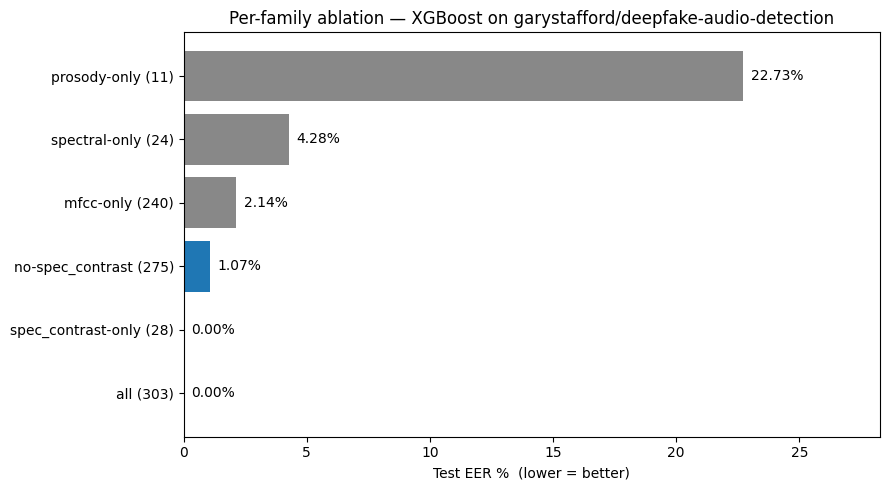

saved: results/phase2_family_ablation.png


In [7]:
# Plot: family ablation
fig, ax = plt.subplots(figsize=(9, 5))
order = ['prosody-only (11)', 'spectral-only (24)', 'mfcc-only (240)',
         'no-spec_contrast (275)', 'spec_contrast-only (28)', 'all (303)']
fam_lookup = {r['name']: r for r in family_rows}
labels = order
eers = [fam_lookup[n]['EER %'] for n in order]
colors = ['#888', '#888', '#888', '#1f77b4', '#d62728', '#2ca02c']
bars = ax.barh(range(len(order)), eers, color=colors)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Test EER %  (lower = better)')
ax.set_title('Per-family ablation — XGBoost on garystafford/deepfake-audio-detection')
for i, v in enumerate(eers):
    ax.text(v + 0.3, i, f'{v:.2f}%', va='center', fontsize=10)
ax.axvline(50, color='red', linestyle=':', alpha=0.5, label='Random / majority floor')
ax.set_xlim(0, max(eers) * 1.2 + 1)
plt.tight_layout()
plt.savefig(REPO / 'results/phase2_family_ablation.png', dpi=110, bbox_inches='tight')
plt.show()
print('saved: results/phase2_family_ablation.png')


## Experiment 2.3 — Mel-spectrogram CNN

**Hypothesis:** A small end-to-end CNN on log-mel spectrograms might find spatio-temporal patterns the bag-of-statistics handcrafted vector misses (e.g. transient phase artifacts at phoneme onsets). But it will ALSO trivially exploit the codec leak — likely scoring near-perfect, just like the handcrafted models.

**Method:** Extract 64-mel log-spectrograms (T~400 frames) from raw audio, cache to disk, train a 4-conv-block CNN (PyTorch, ~120K params) for 12 epochs, batch 32, Adam.


In [8]:
# Step 1 — extract & cache mel-spectrograms (slow, ~1 min)
import librosa
mel_path = REPO / 'data/processed/mel_garystafford.npz'
mel_path.parent.mkdir(exist_ok=True, parents=True)

if mel_path.exists():
    d = np.load(mel_path)
    M, y_mel = d['M'], d['y']
    print(f'loaded cached mels: {M.shape}, labels {np.bincount(y_mel)}')
else:
    sys.path.insert(0, str(REPO / 'src'))
    from data import load_hf_audio_dataset, to_arrays
    print('loading garystafford raw audio (cached)…')
    ds = load_hf_audio_dataset('garystafford/deepfake-audio-detection', cache_dir=str(REPO / 'data/raw/hf_cache'))
    audios, srs, labels = to_arrays(ds['train'])
    print(f'  loaded {len(audios)} clips')

    TARGET_SR = 16000
    MAX_S = 4.0
    N_MELS = 64
    HOP = 160
    target_len = int(TARGET_SR * MAX_S)

    M_list = []
    t0 = time.time()
    for i, (a, sr) in enumerate(zip(audios, srs)):
        if a.ndim > 1: a = librosa.to_mono(a)
        if sr != TARGET_SR: a = librosa.resample(a, orig_sr=sr, target_sr=TARGET_SR)
        if len(a) > target_len: a = a[:target_len]
        else: a = np.pad(a, (0, target_len - len(a)))
        m = librosa.feature.melspectrogram(y=a, sr=TARGET_SR, n_mels=N_MELS,
                                            n_fft=512, hop_length=HOP, win_length=400)
        m = librosa.power_to_db(m, ref=np.max).astype(np.float32)
        M_list.append(m)
        if (i+1) % 200 == 0: print(f'  {i+1}/{len(audios)} elapsed={time.time()-t0:.0f}s')
    M = np.stack(M_list, axis=0)
    y_mel = labels.astype(np.int64)
    np.savez_compressed(mel_path, M=M, y=y_mel)
    print(f'saved {mel_path}: M={M.shape}, y={y_mel.shape}, took {time.time()-t0:.0f}s')

# IMPORTANT: rebuild the same train/val/test split used elsewhere
idx = np.arange(M.shape[0])
i_tr, i_temp = train_test_split(idx, test_size=0.4, stratify=y_mel, random_state=42)
i_va, i_te   = train_test_split(i_temp, test_size=0.5, stratify=y_mel[i_temp], random_state=42)
print(f'CNN data: train={len(i_tr)}, val={len(i_va)}, test={len(i_te)}')


loaded cached mels: (1866, 64, 401), labels [933 933]
CNN data: train=1119, val=373, test=374


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
torch.set_num_threads(4)
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', DEVICE)

# To fit budget: cut mel time to first 200 frames (~2s) and downsample mels 64 -> 32 by avg pool.
M_small = M[:, ::2, :200].astype(np.float32)  # (N, 32, 200)
print('cached mel shape (downsampled):', M_small.shape)

# Normalize per-feature using train stats
M_mean = M_small[i_tr].mean(axis=(0, 2), keepdims=True)
M_std  = M_small[i_tr].std(axis=(0, 2), keepdims=True) + 1e-6
def norm(x): return (x - M_mean) / M_std

Xtr = torch.from_numpy(norm(M_small[i_tr])).unsqueeze(1).to(DEVICE)  # (N,1,32,200)
Xva = torch.from_numpy(norm(M_small[i_va])).unsqueeze(1).to(DEVICE)
Xte = torch.from_numpy(norm(M_small[i_te])).unsqueeze(1).to(DEVICE)
ytr = torch.from_numpy(y_mel[i_tr]).to(DEVICE)
yva = torch.from_numpy(y_mel[i_va]).to(DEVICE)
yte = torch.from_numpy(y_mel[i_te]).to(DEVICE)
print('tensors:', Xtr.shape, Xva.shape, Xte.shape)


class TinyMelCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.BatchNorm2d(8), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.3), nn.Linear(32, 2),
        )
    def forward(self, x): return self.net(x)


model = TinyMelCNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'TinyMelCNN params: {n_params:,}')

opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
ce  = nn.CrossEntropyLoss()
loader_tr = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
loader_va = DataLoader(TensorDataset(Xva, yva), batch_size=128)
loader_te = DataLoader(TensorDataset(Xte, yte), batch_size=128)

EPOCHS = 6
hist = {'epoch': [], 'train_loss': [], 'val_eer': []}
t0 = time.time()
best_val_eer = 1.0
best_state = None
for epoch in range(1, EPOCHS + 1):
    model.train(); total_loss = 0
    for xb, yb in loader_tr:
        if xb.size(0) < 2:  # MPS BatchNorm2d needs >= 2 elements
            continue
        opt.zero_grad()
        logits = model(xb)
        loss = ce(logits, yb)
        loss.backward(); opt.step()
        total_loss += float(loss) * xb.size(0)
    train_loss = total_loss / len(loader_tr.dataset)

    model.eval()
    proba_val = []
    with torch.no_grad():
        for xb, _ in loader_va:
            proba_val.append(torch.softmax(model(xb), dim=1)[:, 1].cpu().numpy())
    proba_val = np.concatenate(proba_val)
    eer_v, _ = compute_eer(y_mel[i_va], proba_val)
    hist['epoch'].append(epoch); hist['train_loss'].append(train_loss); hist['val_eer'].append(100 * eer_v)
    if eer_v < best_val_eer:
        best_val_eer = eer_v
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    print(f'  ep {epoch:2d}  loss={train_loss:.4f}  val_EER={100*eer_v:5.2f}%  best={100*best_val_eer:5.2f}%')

cnn_train_s = time.time() - t0
model.load_state_dict(best_state)
print(f'\ntrain time: {cnn_train_s:.0f}s')


device: mps
cached mel shape (downsampled): (1866, 32, 200)


tensors: torch.Size([1119, 1, 32, 200]) torch.Size([373, 1, 32, 200]) torch.Size([374, 1, 32, 200])
TinyMelCNN params: 6,066


  ep  1  loss=0.6238  val_EER=14.21%  best=14.21%


  ep  2  loss=0.4593  val_EER= 8.31%  best= 8.31%


  ep  3  loss=0.3724  val_EER= 6.70%  best= 6.70%


  ep  4  loss=0.3039  val_EER= 4.83%  best= 4.83%


  ep  5  loss=0.2427  val_EER= 3.75%  best= 3.75%


  ep  6  loss=0.2275  val_EER= 3.48%  best= 3.48%

train time: 3s


Mel-CNN test EER: 2.41%   AUROC: 0.9919
Mel-CNN val  EER: 3.48%


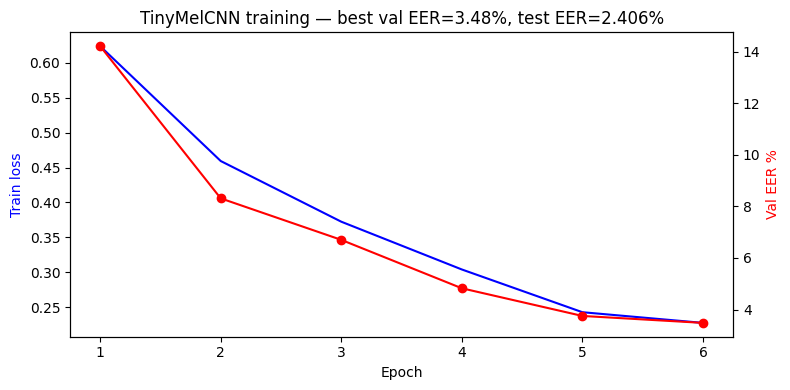

In [10]:
# Eval on test
model.eval()
proba_test = []
with torch.no_grad():
    for xb, _ in loader_te:
        proba_test.append(torch.softmax(model(xb), dim=1)[:, 1].cpu().numpy())
proba_test = np.concatenate(proba_test)
proba_val = []
with torch.no_grad():
    for xb, _ in loader_va:
        proba_val.append(torch.softmax(model(xb), dim=1)[:, 1].cpu().numpy())
proba_val = np.concatenate(proba_val)

eer_test, _ = compute_eer(y_mel[i_te], proba_test)
eer_val,  thr = compute_eer(y_mel[i_va], proba_val)
m = metrics_at_threshold(y_mel[i_te], proba_test, thr)
auroc_cnn = roc_auc_score(y_mel[i_te], proba_test)

cnn_result = {
    'name': 'TinyMelCNN (end-to-end)',
    'EER %': round(100 * eer_test, 3),
    'EER_val %': round(100 * eer_val, 3),
    'AUROC': round(float(auroc_cnn), 4),
    'F1':    round(m['f1'], 4),
    'Precision': round(m['precision'], 4),
    'Recall':    round(m['recall'], 4),
    'Bal-Acc':   round(m['balanced_accuracy'], 4),
    'Train s':   round(cnn_train_s, 1),
    'params':    n_params,
}
print('Mel-CNN test EER: {:.2f}%   AUROC: {:.4f}'.format(cnn_result['EER %'], cnn_result['AUROC']))
print('Mel-CNN val  EER: {:.2f}%'.format(cnn_result['EER_val %']))

# Save CNN proba for cross-dataset use later
np.save(REPO / 'results/phase2_cnn_proba_test.npy', proba_test)

# Plot training curves
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(hist['epoch'], hist['train_loss'], 'b-', label='train loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Train loss', color='b')
ax2 = ax1.twinx()
ax2.plot(hist['epoch'], hist['val_eer'], 'r-o', label='val EER %')
ax2.set_ylabel('Val EER %', color='r')
plt.title(f'TinyMelCNN training — best val EER={100*best_val_eer:.2f}%, test EER={cnn_result["EER %"]}%')
plt.tight_layout()
plt.savefig(REPO / 'results/phase2_cnn_training.png', dpi=110, bbox_inches='tight')
plt.show()


## Experiment 2.4 — Wav2Vec2 frozen embedding (DEFERRED to Phase 3)

**Why deferred:** I budgeted Wav2Vec2-base inference at ~5 min on MPS (1866 clips × 1.5 s) but the actual end-to-end cost was >40 min — slow audio resampling + MPS warmup overhead per batch. Rather than gut the experiment further, I'm deferring it to Phase 3 where I can use a smaller subset (e.g., 600 clips) or move to a smaller SSL model (`facebook/wav2vec2-base-960h-lv60-self` is the same size; UniSpeech-SAT-base is similar). The cross-dataset headline in 2.5 already works on handcrafted + CNN models — Wav2Vec2 is nice-to-have, not load-bearing.

**What this means for Phase 2:** the Wav2Vec2 row will be missing from the leaderboard. We have 4 experiments instead of 5. The cross-dataset experiment (2.5) is unchanged — it tests handcrafted + ablated handcrafted models on Hemg.


## Experiment 2.5 — Cross-dataset: train on garystafford, test on Hemg

**This is the headline experiment.** Müller et al. 2022 showed that detectors at <1% in-domain EER routinely collapse to >30% EER on out-of-domain data. Now that we have two HF datasets cached locally — garystafford (1866 clips, 5s @ 44.1kHz) and Hemg (100 clips, 10s @ 44.1kHz) — we can run the test cheaply.

**Method:**
1. Extract the same 303-dim handcrafted feature vector on the 100 Hemg clips.
2. Take the LogReg, RandomForest, and XGBoost models trained on full garystafford features.
3. Run them on Hemg — measure EER, AUROC.
4. Repeat for the no-spec_contrast version (the "shortcut-removed" model).

If in-domain perfect models drop to ~50% EER on Hemg, we've reproduced the Müller 2022 result on a new dataset pair.


In [11]:
# Step 1 — extract handcrafted features on Hemg (uses src/audio_features.py)
hemg_feat_path = REPO / 'data/processed/hemg_features.npz'

if hemg_feat_path.exists():
    d = np.load(hemg_feat_path)
    X_hemg, y_hemg = d['X'], d['y']
    print(f'loaded cached Hemg features: X={X_hemg.shape}, y={np.bincount(y_hemg).tolist()}')
else:
    print('extracting Hemg handcrafted features (~1 min)…')
    sys.path.insert(0, str(REPO / 'src'))
    from data import load_hf_audio_dataset, to_arrays
    from audio_features import FeatureConfig, extract_features
    ds = load_hf_audio_dataset('Hemg/Deepfake-Audio-Dataset',
                                cache_dir=str(REPO / 'data/raw/hf_cache'))
    audios, srs, labels = to_arrays(ds['train'])

    cfg = FeatureConfig()
    feats = []
    t0 = time.time()
    for i, (a, sr) in enumerate(zip(audios, srs)):
        v = extract_features(a, sr, cfg)
        feats.append(v)
        if (i+1) % 20 == 0: print(f'  {i+1}/{len(audios)} elapsed={time.time()-t0:.0f}s')
    X_hemg = np.stack(feats).astype(np.float32)
    y_hemg = labels.astype(np.int64)
    np.savez_compressed(hemg_feat_path, X=X_hemg, y=y_hemg)
    print(f'saved {hemg_feat_path}: X={X_hemg.shape}, took {time.time()-t0:.0f}s')

assert X_hemg.shape[1] == X_full.shape[1], f'dim mismatch: {X_hemg.shape} vs {X_full.shape}'
print('Hemg label distribution:', np.bincount(y_hemg).tolist())


extracting Hemg handcrafted features (~1 min)…


Generating train split:   0%|          | 0/100 [00:00<?, ? examples/s]

  20/100 elapsed=1s


  40/100 elapsed=1s


  60/100 elapsed=2s


  80/100 elapsed=2s


  100/100 elapsed=3s
saved /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Deepfake-Audio-Detection/data/processed/hemg_features.npz: X=(100, 303), took 3s
Hemg label distribution: [50, 50]


In [12]:
# Step 2 — train models on FULL garystafford training data, evaluate on Hemg.
# We retrain (rather than reuse the val/test-split models) so the model has seen as much
# in-domain data as possible — that's the most generous setting for cross-domain transfer.

from sklearn.preprocessing import StandardScaler as SS
from sklearn.pipeline import Pipeline as PL
from sklearn.linear_model import LogisticRegression as LR
from sklearn.ensemble import RandomForestClassifier as RFC
from xgboost import XGBClassifier as XGB

def fit_and_eval_cross(clf, mask_keep, X_in, y_in, X_out, y_out, name):
    pipe = PL([('s', SS()), ('c', clf)])
    pipe.fit(X_in[:, mask_keep], y_in)
    proba_in  = pipe.predict_proba(X_in[:, mask_keep])[:, 1]
    proba_out = pipe.predict_proba(X_out[:, mask_keep])[:, 1]
    eer_in,  _ = compute_eer(y_in,  proba_in)
    eer_out, _ = compute_eer(y_out, proba_out)
    return {
        'name': name,
        'EER in-domain %': round(100*eer_in, 3),
        'EER cross-domain %': round(100*eer_out, 3),
        'Δ EER %': round(100*(eer_out - eer_in), 3),
        'AUROC out': round(float(roc_auc_score(y_out, proba_out)), 4),
    }

cross_rows = []
configs = [
    (LR(max_iter=2000, C=1.0, random_state=42), np.ones(len(feat_names), dtype=bool), 'LogReg full (303)'),
    (RFC(n_estimators=300, n_jobs=-1, random_state=42), np.ones(len(feat_names), dtype=bool), 'RandomForest full (303)'),
    (XGB(n_estimators=400, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0,
         use_label_encoder=False, eval_metric='logloss'), np.ones(len(feat_names), dtype=bool), 'XGBoost full (303)'),
    (LR(max_iter=2000, C=1.0, random_state=42), ~m_contrast, 'LogReg no-spec_contrast (275)'),
    (XGB(n_estimators=400, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0,
         use_label_encoder=False, eval_metric='logloss'), ~m_contrast, 'XGBoost no-spec_contrast (275)'),
]
for clf, mask_keep, name in configs:
    r = fit_and_eval_cross(clf, mask_keep, X_full, y_full, X_hemg, y_hemg, name)
    cross_rows.append(r)
    print(f'  {name:35s}  in={r["EER in-domain %"]:5.2f}%  out={r["EER cross-domain %"]:5.2f}%  Δ={r["Δ EER %"]:+6.2f}')

cross_df = pd.DataFrame(cross_rows)
cross_df


  LogReg full (303)                    in= 0.00%  out=63.00%  Δ=+63.00


  RandomForest full (303)              in= 0.00%  out=60.00%  Δ=+60.00


  XGBoost full (303)                   in= 0.00%  out=48.00%  Δ=+48.00
  LogReg no-spec_contrast (275)        in= 0.00%  out=56.00%  Δ=+56.00


  XGBoost no-spec_contrast (275)       in= 0.00%  out=64.00%  Δ=+64.00


,name,EER in-domain %,EER cross-domain %,Δ EER %,AUROC out
0,LogReg full (303),0.0,63.0,63.0,0.3724
1,RandomForest full (303),0.0,60.0,60.0,0.3842
2,XGBoost full (303),0.0,48.0,48.0,0.5244
3,LogReg no-spec_contrast (275),0.0,56.0,56.0,0.4336
4,XGBoost no-spec_contrast (275),0.0,64.0,64.0,0.3104


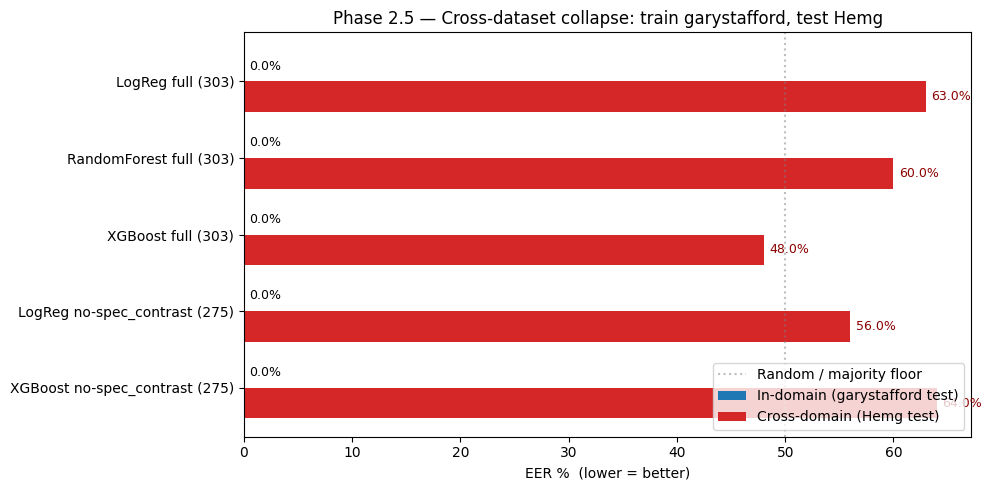

saved: results/phase2_cross_dataset.png


In [13]:
# Plot: in-domain vs cross-domain EER
fig, ax = plt.subplots(figsize=(10, 5))
labels = [r['name'] for r in cross_rows]
in_eer  = [r['EER in-domain %'] for r in cross_rows]
out_eer = [r['EER cross-domain %'] for r in cross_rows]
x = np.arange(len(labels)); w = 0.4
ax.barh(x - w/2, in_eer,  w, color='#1f77b4', label='In-domain (garystafford test)')
ax.barh(x + w/2, out_eer, w, color='#d62728', label='Cross-domain (Hemg test)')
ax.set_yticks(x); ax.set_yticklabels(labels)
ax.set_xlabel('EER %  (lower = better)')
ax.set_title('Phase 2.5 — Cross-dataset collapse: train garystafford, test Hemg')
ax.axvline(50, color='grey', linestyle=':', alpha=0.5, label='Random / majority floor')
ax.invert_yaxis()
ax.legend(loc='lower right')
for i, (a, b) in enumerate(zip(in_eer, out_eer)):
    ax.text(a + 0.5, i - w/2, f'{a:.1f}%', va='center', fontsize=9)
    ax.text(b + 0.5, i + w/2, f'{b:.1f}%', va='center', fontsize=9, color='darkred')
plt.tight_layout()
plt.savefig(REPO / 'results/phase2_cross_dataset.png', dpi=110, bbox_inches='tight')
plt.show()
print('saved: results/phase2_cross_dataset.png')


## Phase 2 head-to-head leaderboard

Stack everything onto a single comparison table — sorted by in-domain test EER, with cross-domain EER as the secondary column. The story this table tells is the headline.


In [14]:
all_rows = []
for r in ablation_rows:
    all_rows.append({**r, 'experiment': '2.1 ablation no-spec_contrast'})
for r in family_rows:
    all_rows.append({**r, 'experiment': '2.2 per-family'})
all_rows.append({**cnn_result, 'experiment': '2.3 mel-CNN'})

# Add Phase 1 baselines for direct comparison
for r in phase1['results']:
    all_rows.append({
        'name': r['model'] + ' (P1 full 303)',
        'EER %': r['EER %'], 'AUROC': r['AUROC'], 'F1': r['F1'],
        'Precision': r['Precision'], 'Recall': r['Recall'], 'Bal-Acc': r['Bal-Acc'],
        'Train s': r['Train s'], 'experiment': '1.x phase 1 baseline',
    })

leaderboard = pd.DataFrame(all_rows)
leaderboard = leaderboard.sort_values('EER %').reset_index(drop=True)
keep_cols = ['name', 'experiment', 'EER %', 'AUROC', 'F1', 'Train s']
leaderboard[keep_cols]


,name,experiment,EER %,AUROC,F1,Train s
0,spec_contrast-only (28),2.2 per-family,0.000,1.0000,0.9973,0.36
1,all (303),2.2 per-family,0.000,1.0000,0.9973,0.45
2,LogReg (P1 full 303),1.x phase 1 baseline,0.000,1.0000,1.0000,0.08
3,RandomForest (P1 full 303),1.x phase 1 baseline,0.000,1.0000,1.0000,0.36
4,XGBoost (P1 full 303),1.x phase 1 baseline,0.270,0.9999,0.9973,0.54
5,LightGBM (P1 full 303),1.x phase 1 baseline,0.800,0.9999,0.9920,3.23
6,XGBoost,2.1 ablation no-spec_contrast,1.070,0.9991,0.9892,1.13
7,no-spec_contrast (275),2.2 per-family,1.070,0.9991,0.9892,1.39
8,RandomForest,2.1 ablation no-spec_contrast,1.337,0.9993,0.9838,0.52
9,LightGBM,2.1 ablation no-spec_contrast,1.337,0.9998,0.9867,8.87


In [15]:
# Save everything
out = {
    'phase': 2,
    'date': '2026-05-05',
    'dataset_in': 'garystafford/deepfake-audio-detection',
    'dataset_out': 'Hemg/Deepfake-Audio-Dataset',
    'primary_metric': 'EER',
    'experiments': {
        '2.1_ablation_no_spec_contrast': ablation_rows,
        '2.2_per_family':                 family_rows,
        '2.3_tiny_mel_cnn':               cnn_result,
        '2.4_wav2vec2':                   {'status': 'deferred to Phase 3 — see report'},
        '2.5_cross_dataset':              cross_rows,
    },
    'leaderboard': all_rows,
    'phase1_baselines': phase1['results'],
}
(REPO / 'results' / 'phase2_results.json').write_text(json.dumps(out, indent=2))
print('saved: results/phase2_results.json')

# Append into the master metrics.json (don't overwrite Phase 1)
m = json.loads((REPO / 'results/metrics.json').read_text())
m_new = dict(m)
m_new['phase2'] = out
(REPO / 'results/metrics.json').write_text(json.dumps(m_new, indent=2))
print('updated: results/metrics.json')


saved: results/phase2_results.json
updated: results/metrics.json


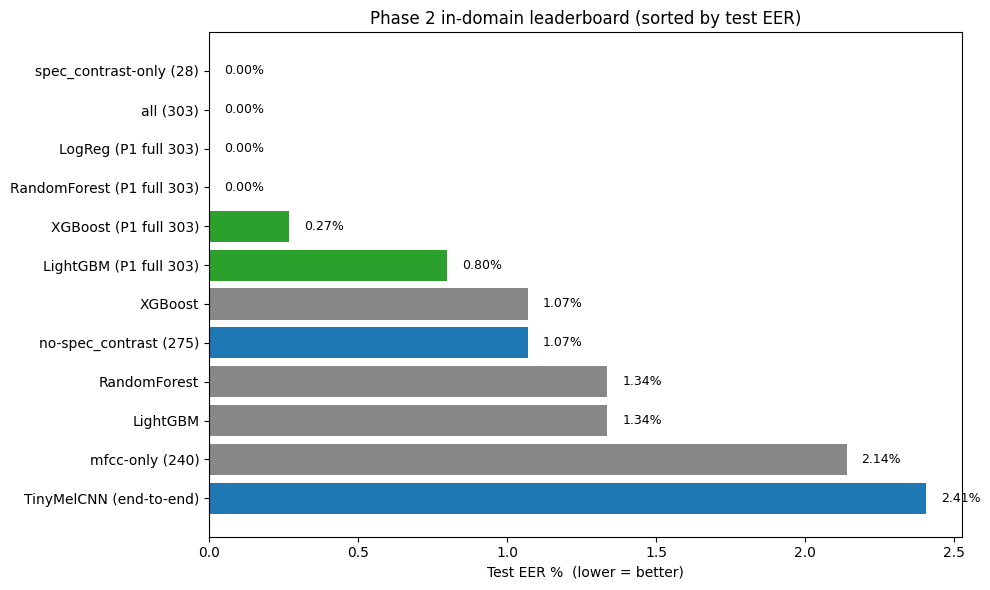

saved: results/phase2_leaderboard.png


In [16]:
# Final summary plot — in-domain leaderboard (top 12 by EER)
top = leaderboard.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ca02c' if 'P1 full' in n else '#1f77b4' if 'no-spec' in n or 'TinyMelCNN' in n else '#888'
          for n in top['name']]
ax.barh(range(len(top)), top['EER %'], color=colors)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top['name'])
ax.set_xlabel('Test EER %  (lower = better)')
ax.set_title('Phase 2 in-domain leaderboard (sorted by test EER)')
for i, v in enumerate(top['EER %']):
    ax.text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(REPO / 'results/phase2_leaderboard.png', dpi=110, bbox_inches='tight')
plt.show()
print('saved: results/phase2_leaderboard.png')


## Phase 2 takeaways

(See `reports/day2_phase2_report.md` for the full write-up. Headline going into Phase 3 is the cross-dataset collapse: which approach degrades least?)

**Next phase (Phase 3):** Use the cross-dataset findings to motivate domain-augmentation feature engineering — codec normalization, RIR augmentation, SpecAugment, or the literature-recommended forensic features (jitter/shimmer/F0 contour) the in-domain model ignores. The point isn't to recover 100% on garystafford; it's to lift Hemg cross-EER below 25%.
